In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read Excel file
df = pd.read_excel('RiskRegister_Group8.xlsx', sheet_name="RiskRegister2")
df.head()

,Risk #,The Risk of/That,Likelihood Score,Impact Score
0,1,Infrastructure upgrade costs for logistics tec...,3,2
1,2,Vendor switching costs for logistics service p...,3,4
2,3,Logistics operating costs in human capital and...,5,6
3,4,Margin reduction due to price competition,9,8
4,5,Capital investment in logistics infrastructure,5,9


In [3]:
# Renamed columns
df.columns = ['risk_id', 'risk_description', 'likelihood_score', 'impact_score']

# Calculate risk score
df['risk_score'] = df['likelihood_score'] * df['impact_score']

In [4]:
# Define severity thresholds
def classify_severity(score):
    if score <= 15:
        return 'Low'
    elif score <= 35:
        return 'Medium'
    else:
        return 'High'

df['severity'] = df['risk_score'].apply(classify_severity)

# Convert severity to numeric scale for heatmap coloring
severity_map = {'Low':1, 'Medium':2, 'High':3}
df['severity_num'] = df['severity'].map(severity_map)

In [5]:
# Create risk labels
df['label'] = 'Risk' + df['risk_id'].astype(str) + ' (' + df['severity'] + ')'

# Build pivot table
pivot_severity = df.groupby(
    ['impact_score','likelihood_score']
)['severity_num'].max().unstack()

# Order axes according to your scoring system
impact_order = [9,8,6,4,2,1]
likelihood_order = [1,3,5,7,9]
pivot_severity = pivot_severity.reindex(index=impact_order, columns=likelihood_order)

In [6]:
# Create annotation matrix
label_matrix = df.groupby(
    ['impact_score','likelihood_score']
)['label'].apply(lambda x:'\n'.join(x)).unstack(fill_value='')

label_matrix = label_matrix.reindex(index=impact_order, columns=likelihood_order, fill_value='')

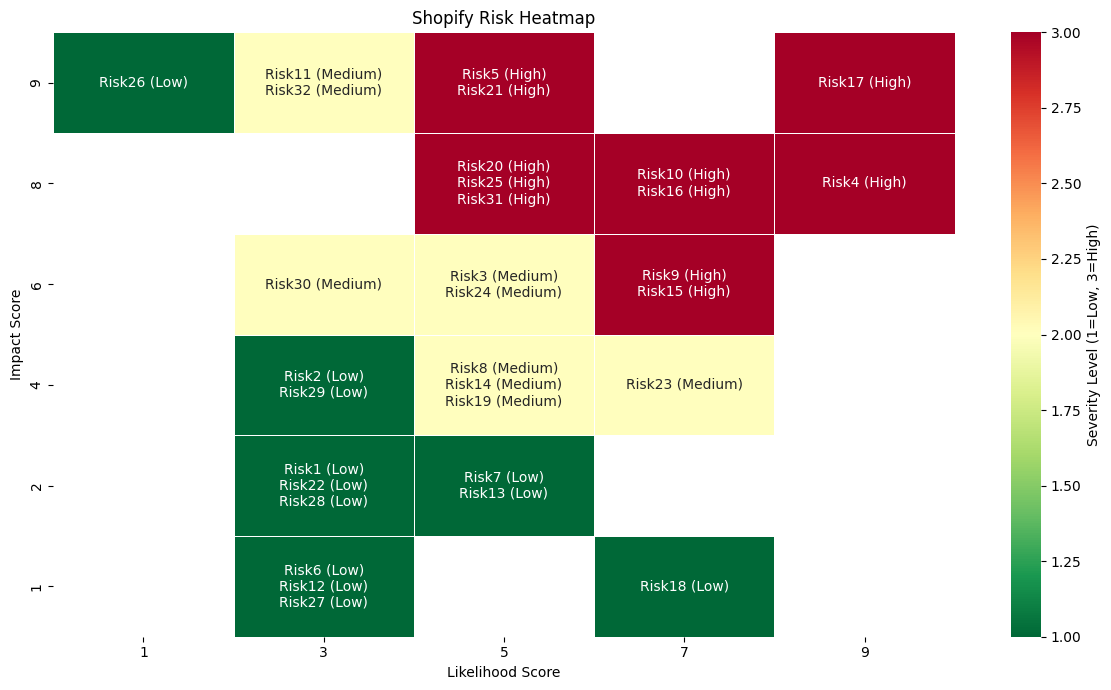

In [7]:
# Plot heatmap
plt.figure(figsize=(12,7))

sns.heatmap(
    pivot_severity,
    annot=label_matrix,
    fmt='',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label':'Severity Level (1=Low, 3=High)'}
)

plt.title("Shopify Risk Heatmap")
plt.xlabel("Likelihood Score")
plt.ylabel("Impact Score")

plt.tight_layout()
plt.show()